In [47]:
from scripts.AbstractExperiments import ExperimentRunner
from scripts.TexTables import SaveDataFrameToTexTemplate
from copy import deepcopy
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

def latex_config_name(name):
    return "$" + name.replace("^0", "^{0}") + "$"


In [2]:
defaultConfig = {"Budget": 3, "Horizon": 6}
inputConfigs = {
    "(Hal)^0": {
        "Theories": [["Hal", "Utility", 0]], 
        "Considerations": [["Hal", "Hal"]]
    },
    "(Law)^0, (Hal)^1": {
        "Theories": [["Hal", "Utility", 1], ["OrdinalLaw", "Ordinal", 0]], 
        "Considerations": [["Hal", "Hal"], ["OrdinalLaw", "OrdinalLaw"]]
    },
    "(Necessity)^0, (Hal)^1": {
        "Theories": [["Hal", "Utility", 1], ["Necessity", "Ordinal", 0]], 
        "Considerations": [["Hal", "Hal"], ["Necessity", "Necessity"]]
    },
    "(Law)^0, (Hal)^0": {
        "Theories": [["Hal", "Utility", 0], ["OrdinalLaw", "Ordinal", 0]], 
        "Considerations": [["Hal", "Hal"], ["OrdinalLaw", "OrdinalLaw"]]
    },
    "(Necessity)^0, (Hal)^0": {
        "Theories": [["Hal", "Utility", 0], ["Necessity", "Ordinal", 0]], 
        "Considerations": [["Hal", "Hal"], ["Necessity", "Necessity"]]
    },
    "(Law)^0, (Necessity)^0, (Hal)^0": {
        "Theories": [["Hal", "Utility", 0], ["Necessity", "Ordinal", 0], ["OrdinalLaw", "Ordinal", 0]], 
        "Considerations": [["Hal", "Hal"], ["Necessity", "Necessity"], ["OrdinalLaw", "OrdinalLaw"]]
    },
    "(Law)^0, (Necessity)^0, (Hal)^1": {
        "Theories": [["Hal", "Utility", 1], ["Necessity", "Ordinal", 0], ["OrdinalLaw", "Ordinal", 0]], 
        "Considerations": [["Hal", "Hal"], ["Necessity", "Necessity"], ["OrdinalLaw", "OrdinalLaw"]]
    },
    #"(Law)^0, (Necessity)^0, (Hal)^0, (Carla)^0": {
    #    "Theories": [["Hal", "Utility", 0], ["Necessity", "Ordinal", 0], ["OrdinalLaw", "Ordinal", 0], ["Carla", "Utility", 0]], 
    #    "Considerations": [["Hal", "Hal"], ["Carla", "Carla"], ["Necessity", "Necessity"], ["OrdinalLaw", "OrdinalLaw"]]
    #},
    #"(Law)^1, (Necessity)^1, (Hal)^0, (Carla)^0": {
    #    "Theories": [["Hal", "Utility", 0], ["Necessity", "Ordinal", 1], ["OrdinalLaw", "Ordinal", 1], ["Carla", "Utility", 0]], 
    #    "Considerations": [["Hal", "Hal"], ["Carla", "Carla"], ["Necessity", "Necessity"], ["OrdinalLaw", "OrdinalLaw"]]
    #}
    
}
if True:
    newConfigs = {}
    for i in range(3, 12):
        for key, value in inputConfigs.items():
            newConfigs[f"H={str(i).rjust(3,'0')}_{key}"] = deepcopy(value)
            newConfigs[f"H={str(i).rjust(3,'0')}_{key}"]["Horizon"] = i

    
inputConfigs = newConfigs


In [3]:
configs = []
for name, dat in inputConfigs.items():
    c = deepcopy(defaultConfig)
    c["Name"] = name
    c["Theories"] = dat["Theories"]
    c["Considerations"] = dat["Considerations"]
    c["Budget"] = dat["Budget"] if "Budget" in dat.keys() else c["Budget"]
    c["Horizon"] = dat["Horizon"] if "Horizon" in dat.keys() else c["Horizon"]
    configs.append(c)
print(configs)

[{'Budget': 3, 'Horizon': 3, 'Name': 'H=003_(Hal)^0', 'Theories': [['Hal', 'Utility', 0]], 'Considerations': [['Hal', 'Hal']]}, {'Budget': 3, 'Horizon': 3, 'Name': 'H=003_(Law)^0, (Hal)^1', 'Theories': [['Hal', 'Utility', 1], ['OrdinalLaw', 'Ordinal', 0]], 'Considerations': [['Hal', 'Hal'], ['OrdinalLaw', 'OrdinalLaw']]}, {'Budget': 3, 'Horizon': 3, 'Name': 'H=003_(Necessity)^0, (Hal)^1', 'Theories': [['Hal', 'Utility', 1], ['Necessity', 'Ordinal', 0]], 'Considerations': [['Hal', 'Hal'], ['Necessity', 'Necessity']]}, {'Budget': 3, 'Horizon': 3, 'Name': 'H=003_(Law)^0, (Hal)^0', 'Theories': [['Hal', 'Utility', 0], ['OrdinalLaw', 'Ordinal', 0]], 'Considerations': [['Hal', 'Hal'], ['OrdinalLaw', 'OrdinalLaw']]}, {'Budget': 3, 'Horizon': 3, 'Name': 'H=003_(Necessity)^0, (Hal)^0', 'Theories': [['Hal', 'Utility', 0], ['Necessity', 'Ordinal', 0]], 'Considerations': [['Hal', 'Hal'], ['Necessity', 'Necessity']]}, {'Budget': 3, 'Horizon': 3, 'Name': 'H=003_(Law)^0, (Necessity)^0, (Hal)^0', 'Theo

In [4]:
Config_repetitions=1
Environment_repetitions=10
er = ExperimentRunner("LostInsulin", configs, MoralPlanner_Location="/../")
er.buildEnvironments(configRepetitions=Config_repetitions)
er.run(configRepetitions=Config_repetitions, envRepetitions=Environment_repetitions)
er.saveResults()

Written LostInsulin MMMDP with 167 states and theories [{'Name': 'Hal', 'Type': 'Utility', 'Rank': 0}].
PATH  /Users/user/Desktop/MyMoralPlanner/MoralPlanner/Notebooks/../Data/Experiments/LostInsulin/2026-06-22_10:30:49/mdps/H=003_(Hal)^0_con0.json

Written LostInsulin MMMDP with 167 states and theories [{'Name': 'Hal', 'Type': 'Utility', 'Rank': 1}, {'Name': 'OrdinalLaw', 'Type': 'Ordinal', 'Rank': 0}].
PATH  /Users/user/Desktop/MyMoralPlanner/MoralPlanner/Notebooks/../Data/Experiments/LostInsulin/2026-06-22_10:30:49/mdps/H=003_(Law)^0, (Hal)^1_con0.json

Written LostInsulin MMMDP with 167 states and theories [{'Name': 'Hal', 'Type': 'Utility', 'Rank': 1}, {'Name': 'Necessity', 'Type': 'Ordinal', 'Rank': 0}].
PATH  /Users/user/Desktop/MyMoralPlanner/MoralPlanner/Notebooks/../Data/Experiments/LostInsulin/2026-06-22_10:30:49/mdps/H=003_(Necessity)^0, (Hal)^1_con0.json

Written LostInsulin MMMDP with 167 states and theories [{'Name': 'Hal', 'Type': 'Utility', 'Rank': 0}, {'Name': 'Ordina

In [5]:

# Format
agg_rules={"Hal": "first",  "Necessity":'first', "Legality":'first', "Num_of_min_non_accept": 'first', "Num_of_sols": 'first',
                "Min_non_accept": 'first', 'Total_time': 'mean'}

df = pd.DataFrame(er.data)
df = df.replace(["", "N/A", "NA", "nan", "None"], np.nan)
df['Config_name'] = df['Config_name'].str.removesuffix("_Hal_Incr")
df['Config_name'] = df['Config_name'].str[6:]
df = df.round(3)
df = df.replace(np.nan, "-")

df['Config_name'] = df['Config_name'].str.replace("Necessity", "N")
df['Config_name'] = df['Config_name'].str.replace("Hal", "H")
df['Config_name'] = df['Config_name'].str.replace("Carla", "C")
df['Config_name'] = df['Config_name'].str.replace("Law", "L")

df['Hal'] = pd.to_numeric(df['Hal'])
df["Total_time"] = pd.to_numeric(df["Total_time"])


df_ = df.copy()

df_ = df_[["Config_name", "Horizon"] + list(agg_rules.keys())]
df_ = (df.groupby(["Config_name", "Horizon"], as_index=False)
      .agg(agg_rules)
      .sort_values(["Config_name", "Horizon"]))




df_ = df_.replace(np.nan, "-")
df_['Necessity'] = df_['Necessity'].str.replace("R=0", "N/A (0)")
df_['Necessity'] = df_['Necessity'].str.replace("R=-1", "P.D. (-1)")
df_['Necessity'] = df_['Necessity'].str.replace("R=-2", "S.M.R. (-2)")
df_['Necessity'] = df_['Necessity'].str.replace("R=-3", "S.H. (-3)")
df_['Necessity'] = df_['Necessity'].str.replace("R=-4", "C.O. (-4)")
df_['Necessity'] = df_['Necessity'].str.replace("R=-5", "B.N. (-5)")

df_['Legality'] = df_['Legality'].str.replace("R=0", "N.V. (0)")
df_['Legality'] = df_['Legality'].str.replace("R=-1", "O.I. (-1)")
df_['Legality'] = df_['Legality'].str.replace("R=-2", "T (-2)")
df_['Legality'] = df_['Legality'].str.replace("R=-3", "B (-3)")
df_['Legality'] = df_['Legality'].str.replace("R=-4", "R (-4)")
df_['Legality'] = df_['Legality'].str.replace("R=-5", "V.T. (-5)")
df_.head(100)

,Config_name,Horizon,Hal,Necessity,Legality,Num_of_min_non_accept,Num_of_sols,Min_non_accept,Total_time
0,(H)^0,3,-60.6997,-,-,1,1,0.0,285.8
1,(H)^0,4,-58.8442,-,-,1,1,0.0,444.5
2,(H)^0,5,-56.9766,-,-,1,1,0.0,822.5
3,(H)^0,6,-55.2698,-,-,1,1,0.0,1093.3
4,(H)^0,7,-53.5391,-,-,1,1,0.0,1584.5
...,...,...,...,...,...,...,...,...,...
58,"(N)^0, (H)^1",7,-55.5186,N/A (0),-,1,3,0.0,4460.0
59,"(N)^0, (H)^1",8,-54.1879,N/A (0),-,1,3,0.0,6527.7
60,"(N)^0, (H)^1",9,-53.0998,N/A (0),-,1,3,0.0,8416.2
61,"(N)^0, (H)^1",10,-52.1969,N/A (0),-,1,4,0.0,12988.0


In [6]:
non_carlas = ['(H)^0', '(L)^0, (H)^1', '(N)^0, (H)^1', '(L)^0, (H)^0', '(N)^0, (H)^0',
              '(L)^0, (N)^0, (H)^0', '(L)^0, (N)^0, (H)^1']

df_horSix = df_[df_['Config_name'].isin(non_carlas)].copy()

df_horSix['Config_name'] = pd.Categorical(
    df_horSix['Config_name'],
    categories=non_carlas,
    ordered=True
)

df_horSix = (
    df_horSix[df_horSix['Horizon'] == 6]
    .sort_values('Config_name')
    .drop(columns=['Horizon'])
)
SaveDataFrameToTexTemplate(df_horSix, f"{er.texTablesFolder}/LI_LawResults.tex", f"{er.texOutFolder}/_Deon_Policy_table.tex", row_template_mode=True, timestamp=er.datetimeNow)

df_horSix.head(1000)

Successfully saved populated LaTeX to /Users/user/Desktop/MyMoralPlanner/MoralPlanner/Notebooks/../Data/Experiments/LostInsulin/2026-06-22_10:30:49/tex/_Deon_Policy_table.tex


,Config_name,Hal,Necessity,Legality,Num_of_min_non_accept,Num_of_sols,Min_non_accept,Total_time
3,(H)^0,-55.2698,-,-,1,1,0.000,1093.3
21,"(L)^0, (H)^1",-65.4548,-,N.V. (0),1,4,0.000,12926.1
57,"(N)^0, (H)^1",-57.1677,N/A (0),-,1,3,0.000,6243.0
12,"(L)^0, (H)^0",-55.2698,-,V.T. (-5),1,4,0.771,12940.5
48,"(N)^0, (H)^0",-55.2698,B.N. (-5),-,1,3,0.386,6277.7
30,"(L)^0, (N)^0, (H)^0",-65.4548,N/A (0),N.V. (0),1,5,1.000,15435.7
39,"(L)^0, (N)^0, (H)^1",-65.4548,N/A (0),N.V. (0),1,5,0.000,15409.1


In [7]:

groups = dict(tuple(df_.groupby("Config_name")))
for conf_name, d in groups.items():
    d = d.drop(columns=['Config_name'])
    SaveDataFrameToTexTemplate(d, f"{er.texTablesFolder}/Horizon_Growth.tex", f"{er.texOutFolder}/{conf_name}_Deon_table.tex", row_template_mode=True, title=conf_name,)
    print(d.to_string())

Successfully saved populated LaTeX to /Users/user/Desktop/MyMoralPlanner/MoralPlanner/Notebooks/../Data/Experiments/LostInsulin/2026-06-22_10:30:49/tex/(H)^0_Deon_table.tex
   Horizon      Hal Necessity Legality  Num_of_min_non_accept  Num_of_sols  Min_non_accept  Total_time
0        3 -60.6997         -        -                      1            1             0.0       285.8
1        4 -58.8442         -        -                      1            1             0.0       444.5
2        5 -56.9766         -        -                      1            1             0.0       822.5
3        6 -55.2698         -        -                      1            1             0.0      1093.3
4        7 -53.5391         -        -                      1            1             0.0      1584.5
5        8 -51.8407         -        -                      1            1             0.0      1925.4
6        9 -50.4421         -        -                      1            1             0.0      2315.4
7  

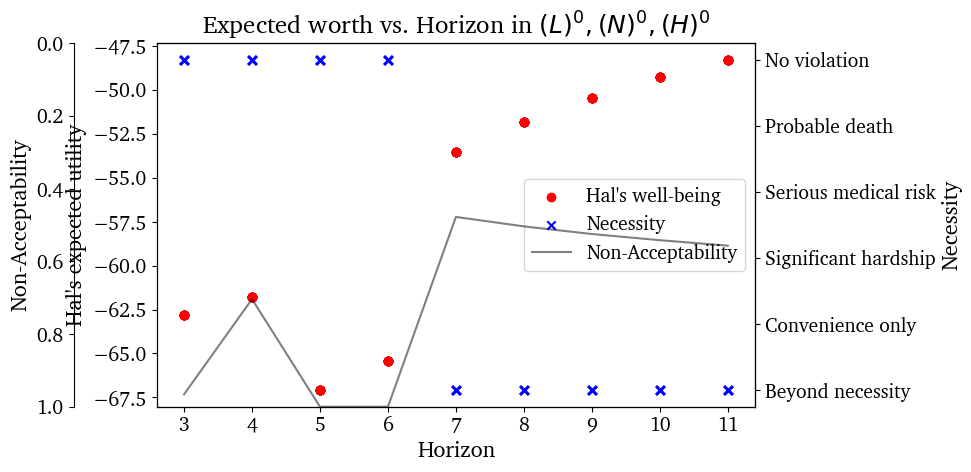

In [8]:
configName = "(L)^0, (N)^0, (H)^0"
dep_var = "Hal"
ord_con_label = "Necessity"
ordinalLabels = {0: "No violation", -1: "Probable death", -2: "Serious medical risk", -3: "Significant hardship", -4: "Convenience only", -5: "Beyond necessity"}

df_ = df.copy()
df_ = df_[df_['Config_name'] == configName].copy()

# 1. FIX UNEVEN SPACING: Force the data to be numeric
df_[dep_var] = pd.to_numeric(df_[dep_var])
df_[ord_con_label] = df_[ord_con_label].str[2:]
df_[ord_con_label] = pd.to_numeric(df_[ord_con_label])
df_['Horizon'] = pd.to_numeric(df_['Horizon'])

fig, ax1 = plt.subplots(figsize=(10, 5))
plt.title(f"Expected worth vs. Horizon in {latex_config_name(configName)}")

# 2. FIX THE LEGEND: Add label="Hal's wellbeing"
ax1.scatter(df_['Horizon'], df_[dep_var], c='red', label="Hal's well-being")
ax1.set_ylabel("Hal's expected utility")
ax1.set_xlabel("Horizon")

ax2 = ax1.twinx() 
# 2. FIX THE LEGEND: Add label="Necessity"
ax2.scatter(df_['Horizon'], df_[ord_con_label], c='blue', marker='x', label=ord_con_label)
ax2.set_ylabel(ord_con_label)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))

min_nec = df_[ord_con_label].min()
max_nec = df_[ord_con_label].max()
tick_positions = np.linspace(min_nec, max_nec, 4) 
ax2.set_yticks(list(ordinalLabels.keys()))
ax2.set_yticklabels(list(ordinalLabels.values()))


ax3 = ax1.twinx()
ax3.yaxis.set_ticks_position('left')
ax3.yaxis.set_label_position('left')
ax3.spines['left'].set_position(('outward', 60))
ax3.spines['left'].set_visible(True)

ax3.set_ylabel('Non-Acceptability')
ax3.set_ylim(max(df_['Min_non_accept']),0)
ax3.plot(df_['Horizon'], df_['Min_non_accept'], c=[0,0,0,0.5], label='Non-Acceptability')


# Generate the legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles3, labels3 = ax3.get_legend_handles_labels()
ax2.legend(handles1 + handles2 + handles3, labels1 + labels2 + labels3, loc='center right')

fig.tight_layout()
plt.show()

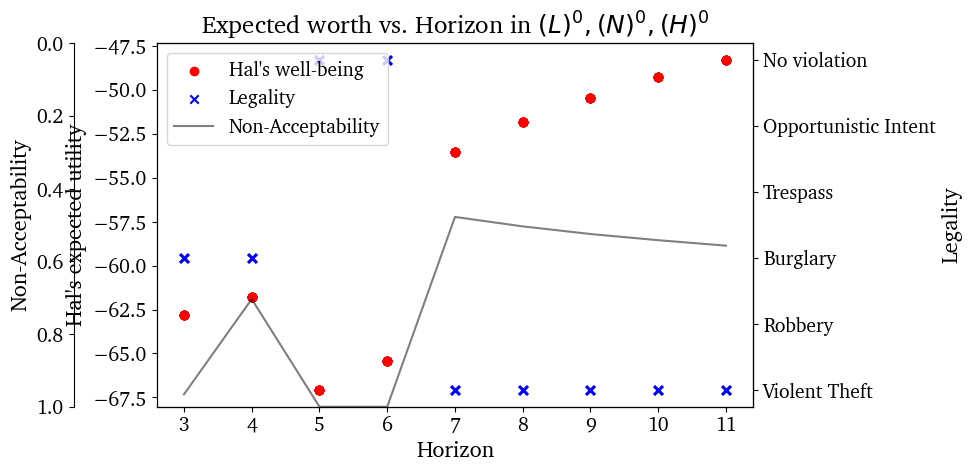

In [9]:


configName = "(L)^0, (N)^0, (H)^0"
dep_var = "Hal"
ord_con_label = "Legality"
ordinalLabels = {0: "No violation", -1: "Opportunistic Intent", -2: "Trespass", -3: "Burglary", -4: "Robbery", -5: "Violent Theft"}

df_ = df.copy()
df_ = df_[df_['Config_name'] == configName].copy()

# 1. FIX UNEVEN SPACING: Force the data to be numeric
df_[dep_var] = pd.to_numeric(df_[dep_var])
df_[ord_con_label] = df_[ord_con_label].str[2:]
df_[ord_con_label] = pd.to_numeric(df_[ord_con_label])
df_['Horizon'] = pd.to_numeric(df_['Horizon'])

fig, ax1 = plt.subplots(figsize=(10, 5))
plt.title(f"Expected worth vs. Horizon in {latex_config_name(configName)}")

# 2. FIX THE LEGEND: Add label="Hal's wellbeing"
ax1.scatter(df_['Horizon'], df_[dep_var], c='red', label="Hal's well-being")
ax1.set_ylabel("Hal's expected utility")
ax1.set_xlabel("Horizon")

ax2 = ax1.twinx() 
ax2.scatter(df_['Horizon'], df_[ord_con_label], c='blue', marker='x', label=ord_con_label)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
ax2.set_ylabel(ord_con_label)

min_nec = df_[ord_con_label].min()
max_nec = df_[ord_con_label].max()
tick_positions = np.linspace(min_nec, max_nec, 4) 
ax2.set_yticks(list(ordinalLabels.keys()))
ax2.set_yticklabels(list(ordinalLabels.values()))


ax3 = ax1.twinx()
ax3.yaxis.set_ticks_position('left')
ax3.yaxis.set_label_position('left')
ax3.spines['left'].set_position(('outward', 60))
ax3.spines['left'].set_visible(True)

ax3.set_ylabel('Non-Acceptability')
ax3.set_ylim(max(df_['Min_non_accept']),0)
ax3.plot(df_['Horizon'], df_['Min_non_accept'], c=[0,0,0,0.5], label='Non-Acceptability')


# Generate the legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles3, labels3 = ax3.get_legend_handles_labels()
ax2.legend(handles1 + handles2 + handles3, labels1 + labels2 + labels3, loc='upper left')

fig.tight_layout()
plt.show()

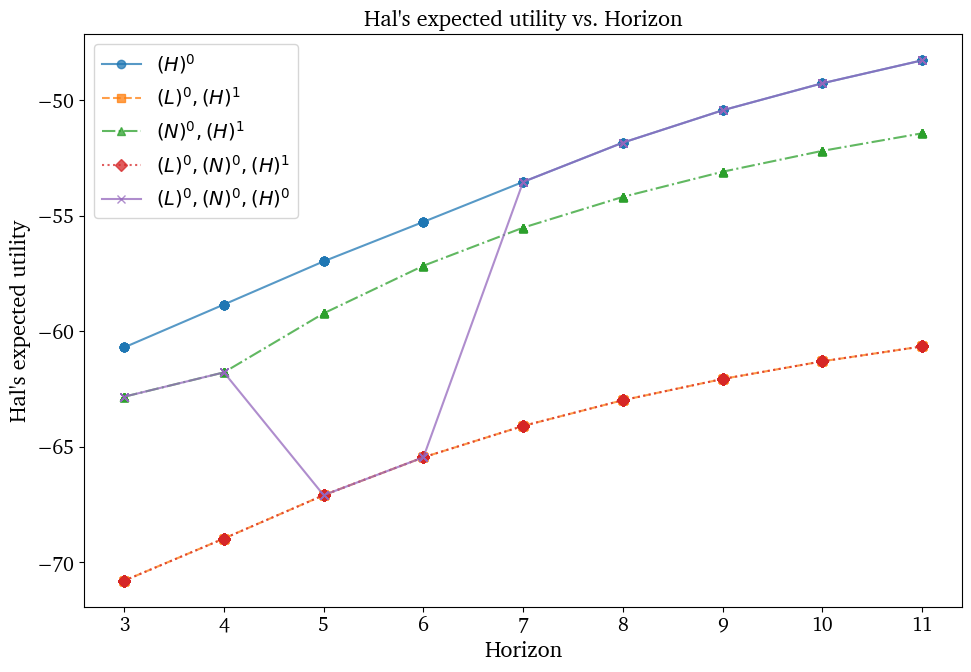

In [23]:
configs_to_show = ["(H)^0",
                        "(L)^0, (H)^1",
                        "(N)^0, (H)^1",
                        "(L)^0, (N)^0, (H)^1",
                        "(L)^0, (N)^0, (H)^0"]
er.plotConfigsAgainstHorizon(configs_to_show, df=df, dep_var="Hal",y_title="Hal's expected utility", title="Hal's expected utility vs. Horizon")

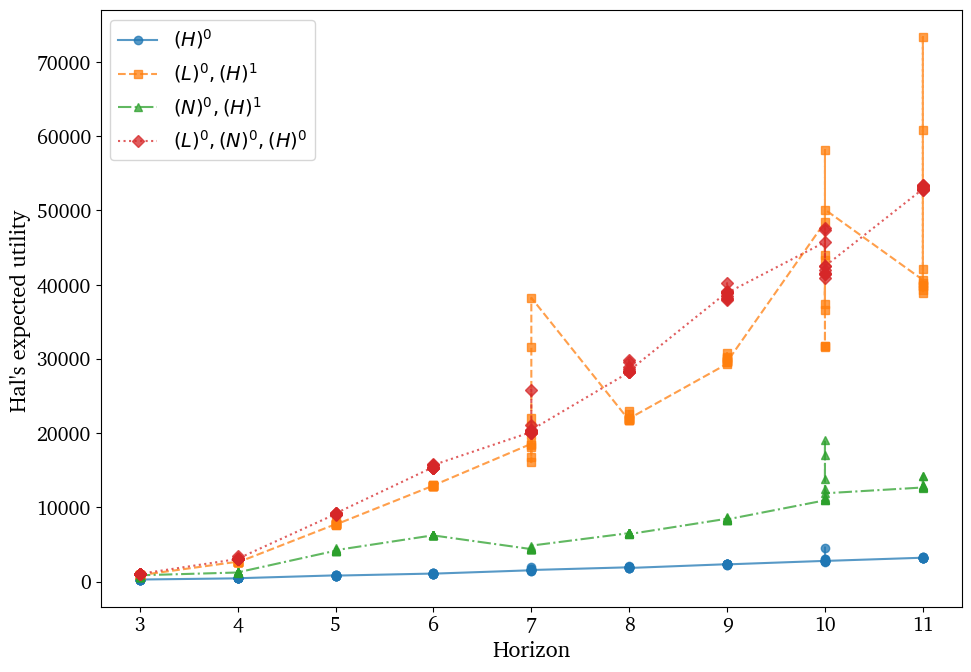

In [26]:
configs_to_show = ["(H)^0",
                        "(L)^0, (H)^1",
                        "(N)^0, (H)^1",
                        "(L)^0, (N)^0, (H)^0"]
er.plotConfigsAgainstHorizon(configs_to_show, df=df, dep_var="Total_time", y_title="Hal's expected utility ")

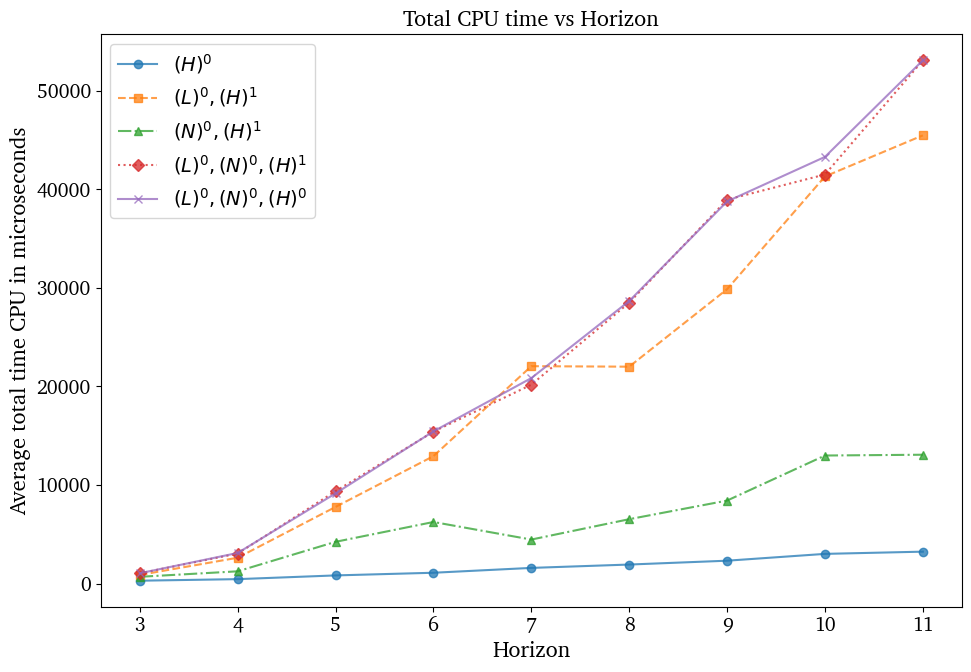

In [51]:
plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

dep_var = "Total_time"

# Make a copy of the whole dataframe, because you want every Config_name
df_ = df.copy()

# Ensure numeric values
df_[dep_var] = pd.to_numeric(df_[dep_var])
df_["Horizon"] = pd.to_numeric(df_["Horizon"])

fig, ax = plt.subplots(figsize=(10, 7))

linestyles = ["-", "--", "-.", ":"]
markers = ["o", "s", "^", "D", "x", "*"]

configs_to_show = ["(H)^0",
                   "(L)^0, (H)^1",
                   "(N)^0, (H)^1",
                   "(L)^0, (N)^0, (H)^1",
                   "(L)^0, (N)^0, (H)^0"]
df_ = df_.groupby(['Config_name', 'Horizon'])["Total_time"].mean().reset_index()

for i, config_name in enumerate(configs_to_show):
    group = df_[df_["Config_name"] == config_name].sort_values("Horizon")
    ax.plot(
        group["Horizon"],
        group[dep_var],
        marker=markers[i  % len(markers)],
        label=latex_config_name(config_name),
        alpha=0.75,
        linewidth=1.5,
        linestyle=linestyles[i % len(linestyles)]
    )

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_title("Total CPU time vs Horizon")
ax.set_xlabel("Horizon")
ax.set_ylabel(f"Average total time CPU in microseconds")

ax.legend(loc="upper left")
fig.tight_layout()
plt.show()


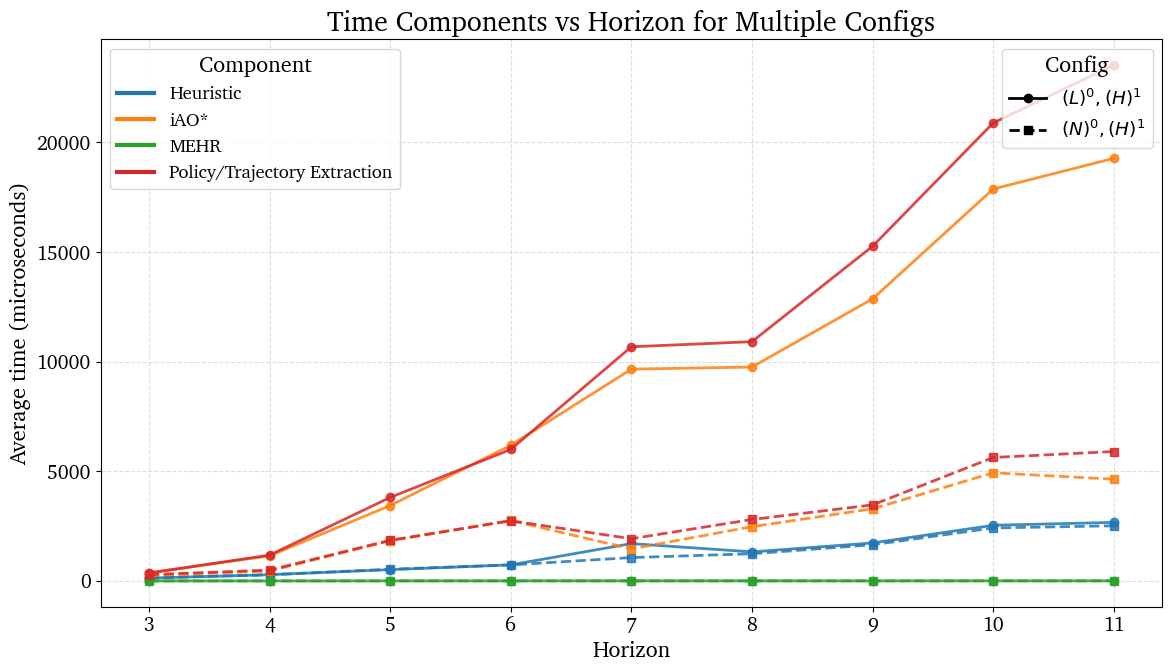

,Config_name,Horizon,Total_time,Heuristic_time,Plan_time,Mehr_time,Sol_time
0,"(L)^0, (H)^1",3,871.1,131.0,374.5,3.5,362.1
1,"(L)^0, (H)^1",4,2617.7,288.2,1146.7,3.3,1179.5
2,"(L)^0, (H)^1",5,7773.2,517.2,3440.2,5.3,3810.5
3,"(L)^0, (H)^1",6,12926.1,735.8,6185.6,5.5,5999.2
4,"(L)^0, (H)^1",7,22052.2,1704.5,9660.0,8.0,10679.7
5,"(L)^0, (H)^1",8,22001.9,1327.2,9755.6,6.3,10912.8
6,"(L)^0, (H)^1",9,29864.7,1734.9,12863.3,5.0,15261.5
7,"(L)^0, (H)^1",10,41303.4,2540.5,17872.3,6.5,20884.1
8,"(L)^0, (H)^1",11,45473.4,2672.7,19272.5,6.2,23522.0
9,"(N)^0, (H)^1",3,682.3,140.5,247.8,2.8,291.2


In [48]:
from matplotlib.lines import Line2D

config_names = ["(L)^0, (H)^1", "(N)^0, (H)^1"]
labels = {"Heuristic_time": "Heuristic", "Mehr_time": "MEHR", "Plan_time": "iAO*", "Sol_time": "Policy/Trajectory Extraction"}

average_durations = df[df['Config_name'].isin(config_names)].copy()
average_durations = average_durations.groupby(['Config_name', 'Horizon'])[ExperimentRunner.time_columns].mean().reset_index()
average_durations['Mehr_time'] = average_durations['Mehr_time'].replace(0, 0.0001)

cols = deepcopy(ExperimentRunner.time_columns)
cols.remove('Total_time')

plt.figure(figsize=(12, 7))

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
component_colors = {col: color_cycle[i % len(color_cycle)] for i, col in enumerate(cols)}
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'D', 'x', '*']

for cfg_idx, config in enumerate(config_names):
    config_group = average_durations[average_durations['Config_name'] == config]
    style = line_styles[cfg_idx % len(line_styles)]
    marker = markers[cfg_idx % len(markers)]
    for column in cols:
        plt.plot(
            config_group['Horizon'],
            config_group[column],
            linestyle=style,
            marker=marker,
            color=component_colors[column],
            label=f"{labels[column]} — {latex_config_name(config)}",
            alpha=0.85,
            linewidth=2,
            markersize=6,
        )

plt.title("Time Components vs Horizon for Multiple Configs")
plt.xlabel("Horizon")
plt.ylabel("Average time (microseconds)")
plt.xticks(ticks=np.arange(min(average_durations['Horizon']), max(average_durations['Horizon']) + 1, 1))

component_handles = [Line2D([0], [0], color=component_colors[col], lw=3) for col in cols]
config_handles = [Line2D([0], [0], color='black', lw=2, linestyle=line_styles[i % len(line_styles)], marker=markers[i % len(markers)]) for i in range(len(config_names))]

legend1 = plt.legend(component_handles, [labels[col] for col in cols], title='Component', loc='upper left', fontsize='small')
legend2 = plt.legend(config_handles, [latex_config_name(c) for c in config_names], title='Config', loc='upper right', fontsize='small')
plt.gca().add_artist(legend1)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
average_durations.head(100)

In [ ]:

df = pd.DataFrame(er.data)
        
average_durations = df.copy()
if (not config_name is None):
    average_durations = average_durations[average_durations['Config_name']==config_name]
average_durations.head(100)


,Config_name,Conf_rep,Env_rep,Theories,Considerations,Total_time,Heuristic_time,Plan_time,Mehr_time,CQ1_time,...,Iterations,Horizon,Min_non_accept,Num_of_min_non_accept,Num_of_sols,Total_Attacks,Total_reachable_policies,Hal,Legality,Necessity


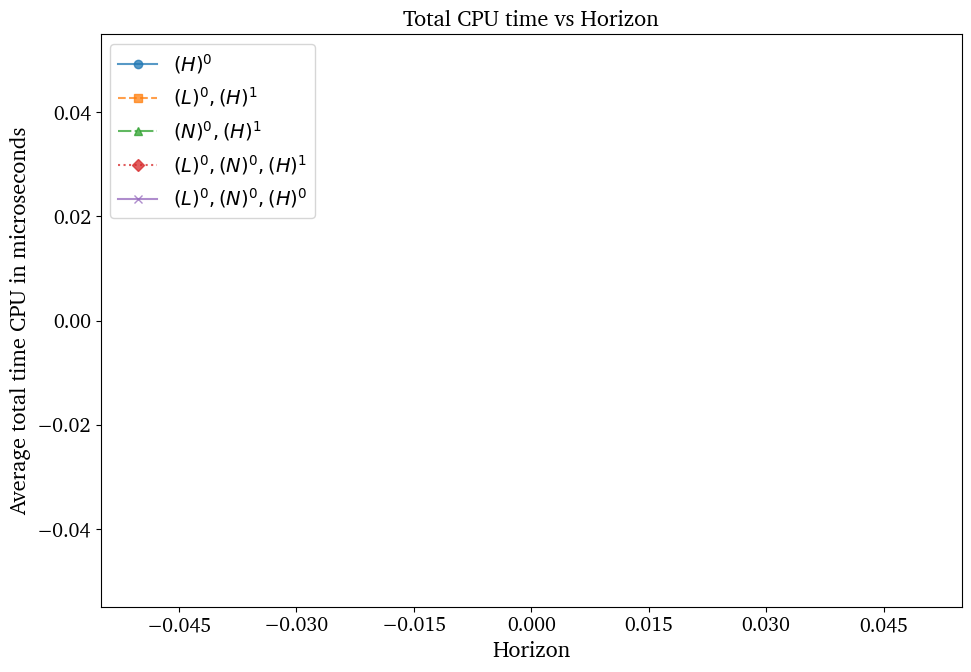

In [ ]:

plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

dep_var = "Total_time"

# Make a copy of the whole dataframe, because you want every Config_name
df_ = df.copy()

# Ensure numeric values
df_[dep_var] = pd.to_numeric(df_[dep_var])
df_["Horizon"] = pd.to_numeric(df_["Horizon"])

fig, ax = plt.subplots(figsize=(10, 7))

linestyles = ["-", "--", "-.", ":"]
markers = ["o", "s", "^", "D", "x", "*"]

configs_to_show = ["(H)^0",
                   "(L)^0, (H)^1",
                   "(N)^0, (H)^1",
                   "(L)^0, (N)^0, (H)^1",
                   "(L)^0, (N)^0, (H)^0"]
for i, config_name in enumerate(configs_to_show):
    group = df_[df_["Config_name"] == config_name].sort_values("Horizon")
    ax.plot(
        group["Horizon"],
        group[dep_var],
        marker=markers[i  % len(markers)],
        label=latex_config_name(config_name),
        alpha=0.75,
        linewidth=1.5,
        linestyle=linestyles[i % len(linestyles)]
    )

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_title("Total CPU time vs Horizon")
ax.set_xlabel("Horizon")
ax.set_ylabel(f"Average total time CPU in microseconds")

ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

